# 기능요구사항

Jupyter notebook에 프로세스 과정을 출력하고 결과 그래프도 출력하세요.

Positive Sentiment, Negative Sentiment에 각각 해당하는 단어들을 모아서 word cloud를 화면에 표시하세요.

Word Cloud를 만들 때 사용할 단어들은 sampling을 통해서 선택하세요.

하나의 word cloud에는 최대 200개의 단어만 표시하세요.

In [4]:
import pandas as pd
import matplotlib
import wordcloud
import matplotlib.pyplot as plt


# 데이터 컬럼 설명

target : 트윗의 감성 극성 (0 = 부정, 2 = 중립, 4 = 긍정)

ids    : 트윗의 고유 ID 예: 2087

date   : 트윗이 작성된 날짜와 시간 예: Sat May 16 23:58:44 UTC 2009

flag   : 트윗 검색 쿼리 정보 예: lyx
         쿼리가 없는 경우 NO_QUERY 값이 사용됨

user   : 트윗을 작성한 사용자 이름 예: robotickilldozr

text   : 트윗 본문 내용 예: Lyx is cool

In [5]:
#컬럼명이 없어서 생성
columns = ['target', 'ids', 'date', 'flag', 'user', 'text']

df = pd.read_csv(
    '../../../data/sentiment.csv',
    encoding='latin-1',
    header=None,
    names=columns
)

In [9]:
# positive, negative 문장  1000개 샘플링
positive_sample = df[df["target"] == 4].sample(n=1000, random_state=42)
negative_sample = df[df["target"] == 0].sample(n=1000, random_state=42)

# postive , negative 텍스트를 이어 붙힘
positive_text = " ".join(df[df["target"] == 4]["text"].astype(str))
negative_text = " ".join(df[df["target"] == 0]["text"].astype(str))

# wordcloud를 활용하여 빈도수 확인 (positive)
positive_wc = wordcloud.WordCloud(
    width=800,
    height=400,
    max_font_size=200,
    max_words=200,
    background_color="white"
    ).generate(positive_text)

# wordcloud를 활용하여 빈도수 확인 (negative)
negative_wc = wordcloud.WordCloud(
    width=800,
    height=400,
    max_font_size=200,
    max_words=200,
    background_color="white"
    ).generate(negative_text)

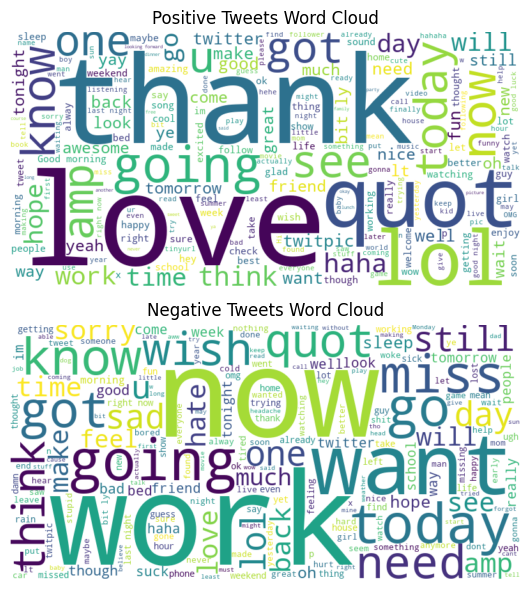

In [10]:
# matplotlib를 활용하여 시각화
plt.figure(figsize=(6, 6))

plt.subplot(2, 1, 1)
plt.imshow(positive_wc, interpolation="bilinear")
plt.title("Positive Tweets Word Cloud")
plt.axis("off")

plt.subplot(2, 1, 2)
plt.imshow(negative_wc, interpolation="bilinear")
plt.title("Negative Tweets Word Cloud")
plt.axis("off")

plt.tight_layout()
plt.show()